In [9]:
import numpy as np
from pathlib import Path
from math import comb

from ramsey.RArchive import RSQLiteArchive
from ramsey.RGraph import RGraph
from ramsey.RProblem import RProblem
from ramsey.RColoring import RColoring
from ramsey.RConstruction import RRandomConstruction
from ramsey.RState import RSearchState



# ---------------------------------------------------------
# Graph and archive.
# ---------------------------------------------------------

graph = RGraph(
    RProblem.r55(
        n_vertices=43,
    )
)

archive = RSQLiteArchive(
    Path("../data/ramsey_colorings.sqlite3")
)

NUM_GRAPHS = 10

rng = np.random.default_rng(12345)

construction = RRandomConstruction(rng)

colorings = [construction.construct(graph) for _ in range(NUM_GRAPHS)]

states = [RSearchState(coloring) for coloring in colorings]

histograms = [state.histogram.copy() for state in states]


# ---------------------------------------------------------
# Load the ten lowest-score archived colorings.
# ---------------------------------------------------------\

# records = archive.best_colorings(
#     limit=10,
#     graph=graph,
# )

# best_colorings = [
#     archive.load_coloring(
#         record.coloring_id,
#         graph,
#     )
#     for record in records
# ]
#
# print(len(best_colorings))
#
# ---------------------------------------------------------
# Report their K5 histograms.
# ---------------------------------------------------------

for i in range(len(states)):
    print(
        f"S={states[i].score:4d} | "
        f"H0={histograms[i][0]:4d} | "
        f"H10={histograms[i][10]:4d}"
    )


S=1679 | H0=1220 | H10= 459
S=1932 | H0=1106 | H10= 826
S=1383 | H0= 849 | H10= 534
S=2330 | H0=1782 | H10= 548
S=1573 | H0= 916 | H10= 657
S=2299 | H0= 974 | H10=1325
S=2625 | H0= 536 | H10=2089
S=1629 | H0= 934 | H10= 695
S=1961 | H0= 541 | H10=1420
S=2496 | H0=1567 | H10= 929


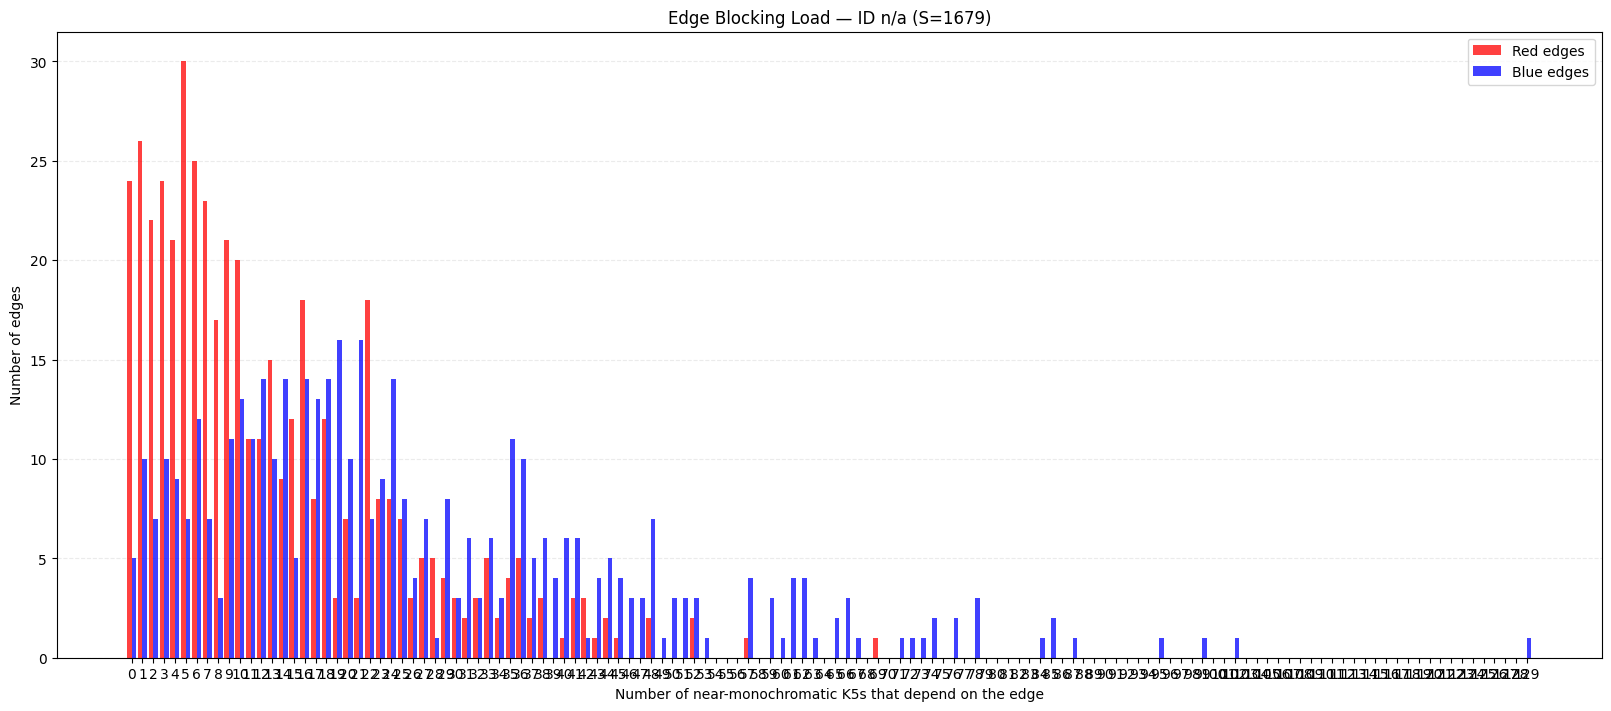

In [11]:
# Report their K5 histograms.
import matplotlib.pyplot as plt
import numpy as np


state = states[0]

profiles = state.action_profiles

red_mask = (
    state.colors == 0
)

blue_mask = (
    state.colors == 1
)


# ---------------------------------------------------------
# Exact blocking load for every edge.
# ---------------------------------------------------------

blocking_load = np.zeros(
    state.number_of_edges,
    dtype=np.uint16,
)

# Blue edge: number of H1 K5s containing it.
blocking_load[
    blue_mask
] = profiles[
    blue_mask,
    1,
]

# Red edge: number of H9 K5s containing it.
blocking_load[
    red_mask
] = profiles[
    red_mask,
    9,
]


# ---------------------------------------------------------
# Exact integer-frequency distributions.
# ---------------------------------------------------------

maximum_load = int(
    blocking_load.max()
)

red_distribution = np.bincount(
    blocking_load[red_mask],
    minlength=maximum_load + 1,
)

blue_distribution = np.bincount(
    blocking_load[blue_mask],
    minlength=maximum_load + 1,
)

loads = np.arange(
    maximum_load + 1
)


# ---------------------------------------------------------
# Plot.
# ---------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(16, 7),
    constrained_layout=True,
)

width = 0.42

ax.bar(
    loads - width / 2,
    red_distribution,
    width=width,
    color="red",
    alpha=0.75,
    label="Red edges",
)

ax.bar(
    loads + width / 2,
    blue_distribution,
    width=width,
    color="blue",
    alpha=0.75,
    label="Blue edges",
)

ax.set_xlabel(
    "Number of near-monochromatic K5s "
    "that depend on the edge"
)

ax.set_ylabel(
    "Number of edges"
)

ax.set_title(
    f"Edge Blocking Load — "
    f"ID {"n/a"} "
    f"(S={state.score})"
)

ax.set_xticks(
    loads
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25,
)

ax.set_axisbelow(True)

ax.legend()

plt.show()

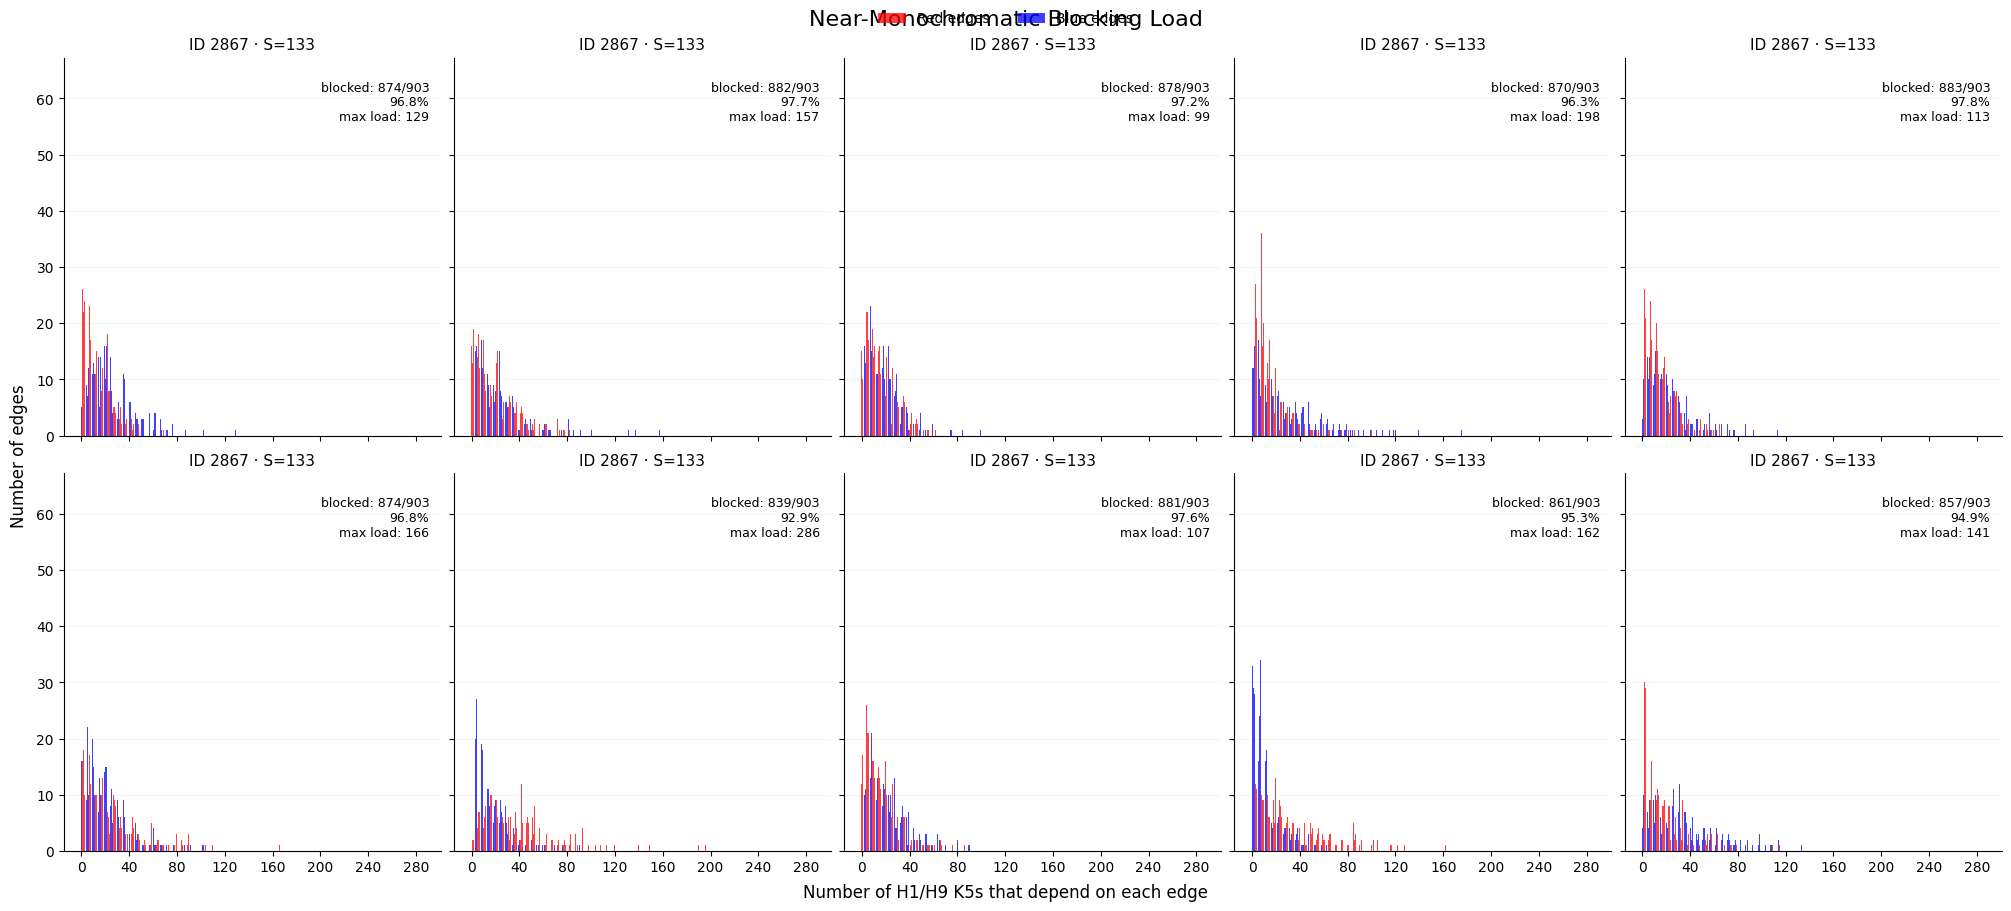

In [12]:
import matplotlib.pyplot as plt
import numpy as np

from matplotlib.ticker import MaxNLocator
from ramsey.RState import RSearchState


# ---------------------------------------------------------
# Calculate blocking loads for all ten colorings.
# ---------------------------------------------------------

blocking_results = []

for state in states:

    profiles = state.action_profiles

    red_mask = (
        state.colors == 0
    )

    blue_mask = (
        state.colors == 1
    )

    blocking_load = np.zeros(
        state.number_of_edges,
        dtype=np.uint16,
    )

    # Blue edge -> H1 dependency count.
    blocking_load[
        blue_mask
    ] = profiles[
        blue_mask,
        1,
    ]

    # Red edge -> H9 dependency count.
    blocking_load[
        red_mask
    ] = profiles[
        red_mask,
        9,
    ]

    blocking_results.append(
        {
            "archived": archived,
            "red": blocking_load[
                red_mask
            ],
            "blue": blocking_load[
                blue_mask
            ],
            "all": blocking_load,
        }
    )


# ---------------------------------------------------------
# Establish one common range.
# ---------------------------------------------------------

maximum_load = max(
    int(result["all"].max())
    for result in blocking_results
)

loads = np.arange(
    maximum_load + 1
)


# ---------------------------------------------------------
# Plot all ten as small multiples.
# ---------------------------------------------------------

fig, axes = plt.subplots(
    2,
    5,
    figsize=(20, 9),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

axes = axes.ravel()

width = 0.42


for ax, result in zip(
    axes,
    blocking_results,
):
    archived = result["archived"]

    red_values = result["red"]
    blue_values = result["blue"]
    all_values = result["all"]

    red_distribution = np.bincount(
        red_values,
        minlength=maximum_load + 1,
    )

    blue_distribution = np.bincount(
        blue_values,
        minlength=maximum_load + 1,
    )

    ax.bar(
        loads - width / 2,
        red_distribution,
        width=width,
        color="red",
        alpha=0.75,
        label="Red edges",
    )

    ax.bar(
        loads + width / 2,
        blue_distribution,
        width=width,
        color="blue",
        alpha=0.75,
        label="Blue edges",
    )

    blocked_count = int(
        np.count_nonzero(
            all_values
        )
    )

    blocked_fraction = (
        blocked_count
        / len(all_values)
    )

    ax.set_title(
        f"ID {archived.record.coloring_id} "
        f"· S={archived.record.score}",
        fontsize=11,
    )

    ax.text(
        0.97,
        0.94,
        (
            f"blocked: "
            f"{blocked_count}/903\n"
            f"{blocked_fraction:.1%}\n"
            f"max load: "
            f"{int(all_values.max())}"
        ),
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=9,
    )

    ax.grid(
        axis="y",
        linestyle="--",
        linewidth=0.6,
        alpha=0.20,
    )

    ax.set_axisbelow(True)

    ax.xaxis.set_major_locator(
        MaxNLocator(
            integer=True,
            nbins=10,
        )
    )

    ax.spines["top"].set_visible(
        False
    )

    ax.spines["right"].set_visible(
        False
    )


handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncols=2,
    frameon=False,
)

fig.suptitle(
    "Near-Monochromatic Blocking Load",
    fontsize=16,
)

fig.supxlabel(
    "Number of H1/H9 K5s that depend on each edge",
    fontsize=12,
)

fig.supylabel(
    "Number of edges",
    fontsize=12,
)

plt.show()